In [2]:
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem,Draw
import numpy as np
import pandas as pd

In [4]:
df=pd.DataFrame([
    [1,2,3],
    [4,5,6],
    [7,8,9]
])
df.index=['2px','2py','2pz']
df

,0,1,2
2px,1,2,3
2py,4,5,6
2pz,7,8,9


In [8]:
df.loc[['2px','2py'],:].iloc[:,1]

2px    2
2py    5
Name: 1, dtype: int64

In [9]:
x=[1,2,3]

In [11]:
x[:-1]

[1, 2]

In [3]:
x=np.array([-1,0,1])

In [5]:
x=np.where(x>0,0,x)
x

array([-1,  0,  0])

In [18]:
smi='[*]:[*](:[*]):[*]'

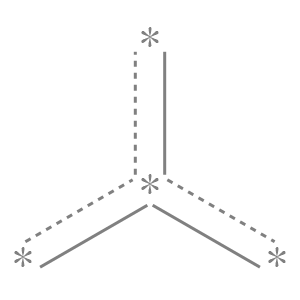

In [19]:
mol=Chem.MolFromSmiles(smi)
Draw.MolToImage(mol)

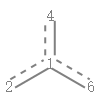

In [26]:
atoms=mol.GetAtoms()
index=[2,1,6,4]
for i,atom in enumerate(atoms):
    atom.SetProp('atomLabel',f'{index[i]}')
Draw.MolToImage(mol,size=(100,100))

In [27]:
Draw.MolToImageFile(mol,'基准.png')

In [28]:
x=[1,2,3,4,5,6]
[(i if i<6 else None) for i in x]

[1, 2, 3, 4, 5, None]

In [31]:
centerPos=np.array([1,1,1])
connectPos=np.array([2,2,2])
[centerPos+(connectPos-centerPos)*(i/9) for i in range(10)]

[array([1., 1., 1.]),
 array([1.11111111, 1.11111111, 1.11111111]),
 array([1.22222222, 1.22222222, 1.22222222]),
 array([1.33333333, 1.33333333, 1.33333333]),
 array([1.44444444, 1.44444444, 1.44444444]),
 array([1.55555556, 1.55555556, 1.55555556]),
 array([1.66666667, 1.66666667, 1.66666667]),
 array([1.77777778, 1.77777778, 1.77777778]),
 array([1.88888889, 1.88888889, 1.88888889]),
 array([2., 2., 2.])]

In [99]:
# 设计一个函数，可以根据三个点获取平面
import sympy
x1,y1,z1=sympy.symbols('x1,y1,z1')
x2,y2,z2=sympy.symbols('x2,y2,z2')
x3,y3,z3=sympy.symbols('x3,y3,z3')
A,B,C,D=sympy.symbols('A,B,C,D')
x1,y1,z1=[1,0,-1.5]
x2,y2,z2=[0,-1.3,0.75]
x3,y3,z3=[0,1.3,0.75]
res=sympy.solve([
    A*x1+B*y1+C*z1+D,
    A*x2+B*y2+C*z2+D,
    A*x3+B*y3+C*z3+D,
],[A,B,C,D])
print(res)
# 平面的法向量即为(A,B,C)

{A: -3.0*D, B: 0.0, C: -1.33333333333333*D}


In [100]:
list(res.keys()),list(res.values())

([A, B, C], [-3.0*D, 0.0, -1.33333333333333*D])

In [110]:
if A not in list(res.keys()):
    n1=np.array([1,0,0])
if B not in list(res.keys()):
    n1=np.array([0,1,0])
if C not in list(res.keys()):
    n1=np.array([0,0,1])
if D not in list(res.keys()):
    n1=np.array([float(res[each].subs(D,1)) for each in [A,B,C]])
    n1=n1=n1/(np.sum(n1**2))**0.5
n1

array([-0.91381155,  0.        , -0.40613847])

In [115]:
import numpy as np

In [126]:
a=[ 0.08060388 ,0.04358577  ,0.0091233  ,-0.01399368 ,-0.0251566 , -0.02861346,-0.02853549 ,-0.02700232 ,-0.02462903, -0.02164524]
b=[-0.08060388 ,-0.04358577 ,-0.0091233 ,  0.01399368  ,0.0251566 ,  0.02861346,0.02853549 , 0.02700232 , 0.02462903,  0.02164524]
np.array(a)+np.array(b[::-1])

array([ 0.10224912,  0.0682148 ,  0.03612562,  0.01454181,  0.00345686,
       -0.00345686, -0.01454181, -0.03612562, -0.0682148 , -0.10224912])

In [125]:
b[::-1]

[0.02164524,
 0.02462903,
 0.02700232,
 0.02853549,
 0.02861346,
 0.0251566,
 0.01399368,
 -0.0091233,
 -0.04358577,
 -0.08060388]

In [1]:
10%10

0

In [29]:
# 计算两向量间夹角
import numpy as np
from math import pi
n1=np.array([1,0,0])
n2=np.array([-1,0,0])
np.arccos(np.dot(n1,n2)/((np.sum(n1**2))**0.5+(np.sum(n1**2))**0.5))/pi

0.6666666666666667

In [30]:
np.dot(n1,n2)

-1

In [33]:
np.arccos(np.dot(n1,n2)/(np.sqrt(np.dot(n1,n1))*np.sqrt(np.dot(n2,n2))))/pi

1.0

In [5]:
def add(num):
    if num>10:
        print(num)
        return num
    else:
        return add(num+1)
print(add(0))

11
11
